<a href="https://colab.research.google.com/github/gauravbh024/primetrade.ai_assignment/blob/main/notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merged Rows: 211224


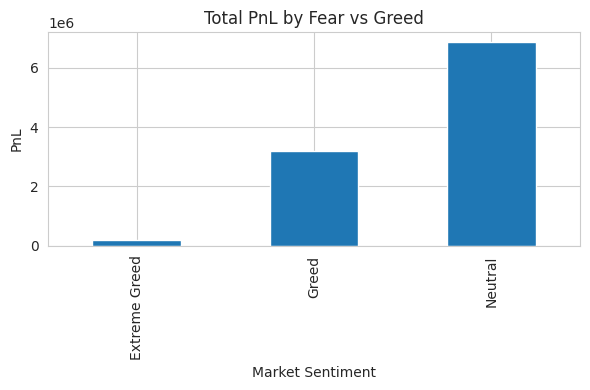

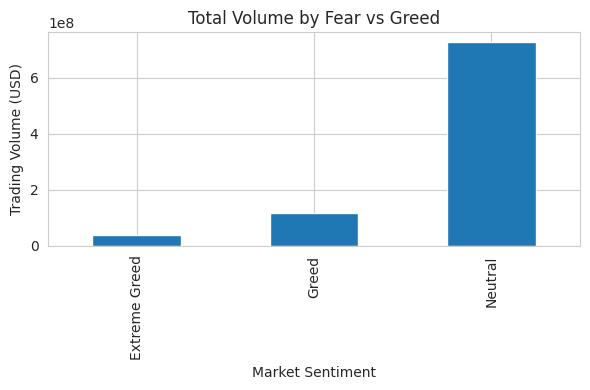

🎉 DONE! Charts are saved in /outputs/


In [25]:


import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("outputs", exist_ok=True)



hist = pd.read_csv('/content/historical_data.csv')
sent = pd.read_csv('/content/fear_greed_index.csv')

# Clean column names
hist.columns = hist.columns.str.strip().str.lower()
sent.columns = sent.columns.str.strip().str.lower()



hist['date'] = pd.to_datetime(hist['timestamp'], unit='ms')
sent['date'] = pd.to_datetime(sent['date'])

# Sort both datasets
hist = hist.sort_values('date')
sent = sent.sort_values('date')



merged = pd.merge_asof(
    hist,
    sent[['date', 'classification']],
    on='date',
    direction='nearest',
    tolerance=pd.Timedelta('30 days')  # allow up to 30-day tolerance
)

# Check merge result
print("Merged Rows:", len(merged))
merged.head()



# Closed PnL column may have different names; auto-detect
pnl_col = None
for col in merged.columns:
    if 'pnl' in col.lower():
        pnl_col = col
        break

if pnl_col is None:
    raise ValueError("PnL column not found. Check CSV column names.")



pnl_plot = merged.groupby('classification')[pnl_col].sum()

plt.figure(figsize=(6,4))
pnl_plot.plot(kind='bar')
plt.title("Total PnL by Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("PnL")
plt.tight_layout()
plt.savefig("outputs/pnl_fear_greed.png")
plt.show()



# detect volume column
vol_col = None
for col in merged.columns:
    if 'size usd' in col.lower():
        vol_col = col
        break

if vol_col is None:
    raise ValueError("Volume column not found.")

vol_plot = merged.groupby('classification')[vol_col].sum()

plt.figure(figsize=(6,4))
vol_plot.plot(kind='bar')
plt.title("Total Volume by Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Trading Volume (USD)")
plt.tight_layout()
plt.savefig("outputs/volume_fear_greed.png")
plt.show()



merged.to_csv("csv_files/merged_output.csv", index=False)

print("🎉 DONE! Charts are saved in /outputs/")


Historical rows: (211224, 17)
Sentiment rows: (2644, 4)
Merged rows: (0, 18)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification


Historical unique dates: [datetime.date(1970, 1, 1)]
Sentiment unique dates: [datetime.date(2018, 2, 1) datetime.date(2018, 2, 2)
 datetime.date(2018, 2, 3) datetime.date(2018, 2, 4)
 datetime.date(2018, 2, 5) datetime.date(2018, 2, 6)
 datetime.date(2018, 2, 7) datetime.date(2018, 2, 8)
 datetime.date(2018, 2, 9) datetime.date(2018, 2, 10)]


,timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12
5,1.730000e+12
6,1.730000e+12
7,1.730000e+12
8,1.730000e+12
9,1.730000e+12


Merged Rows: (184263, 18)


[datetime.date(2024, 10, 27) datetime.date(2025, 2, 19)
 datetime.date(2025, 6, 15) datetime.date(2024, 3, 9)
 datetime.date(2024, 7, 3) datetime.date(2023, 11, 14)
 datetime.date(2023, 3, 28)]
[datetime.date(2018, 2, 1) datetime.date(2018, 2, 2)
 datetime.date(2018, 2, 3) datetime.date(2018, 2, 4)
 datetime.date(2018, 2, 5) datetime.date(2018, 2, 6)
 datetime.date(2018, 2, 7) datetime.date(2018, 2, 8)
 datetime.date(2018, 2, 9) datetime.date(2018, 2, 10)
 datetime.date(2018, 2, 11) datetime.date(2018, 2, 12)
 datetime.date(2018, 2, 13) datetime.date(2018, 2, 14)
 datetime.date(2018, 2, 15) datetime.date(2018, 2, 16)
 datetime.date(2018, 2, 17) datetime.date(2018, 2, 18)
 datetime.date(2018, 2, 19) datetime.date(2018, 2, 20)]


211224